# OT in linear ICA

#### In this notebook, I test the newest (06.03.2026) implementation of OT based ICA with a mixture of discrete distribution

In [1]:
import numpy as np
import torch
import pandas as pd
from sklearn.decomposition import FastICA
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. The Bernoulli/Rademacher Trap Generator
# ==========================================

def generate_bernoulli_mixture(n_dim, n_samples, seed=None):
    """
    Generates a mixture of independent centered Bernoulli {-1, 1} sources.
    This naturally has zero mean and unit variance.
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    # Generate independent discrete sources: -1 or 1
    S = np.random.choice([-1.0, 1.0], size=(n_dim, n_samples))
    
    # Generate a well-conditioned random mixing matrix A
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [3]:
def amari_error(W, A):
    """
    Computes the Amari Error to evaluate the performance of ICA.
    An error close to 0 indicates perfect separation.
    
    W: Estimated unmixing matrix (n_components, n_features)
    A: True mixing matrix (n_features, n_sources)
    """
    # P is the global matrix representing the combined effect of mixing and unmixing
    P = np.dot(W, A)
    P_abs = np.abs(P)
    
    # 1. Sum of row-wise errors
    row_max = np.max(P_abs, axis=1, keepdims=True)
    row_term = np.sum(P_abs / row_max, axis=1) - 1.0
    
    # 2. Sum of column-wise errors
    col_max = np.max(P_abs, axis=0, keepdims=True)
    col_term = np.sum(P_abs / col_max, axis=0) - 1.0
    
    # Average over the number of components
    n = P.shape[0]
    return (np.sum(row_term) + np.sum(col_term)) / (2 * n)

In [4]:
# ==========================================
# 2. Parallel Worker Function (GPU Enabled)
# ==========================================

def run_bernoulli_trial(dim, trial, n_samples):
    torch.set_num_threads(1) 
    trial_results = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_torch, A_true = generate_bernoulli_mixture(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    X_np = X_torch.cpu().numpy()
    
    # --- FastICA ---
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'FastICA', 'Amari Error': score_fast})
    
    # --- W-ICA (Stiefel + Gaussian Dithering) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        n_restarts = dim * 4 if dim * 4 < 150 else 150
        
        # 1. Deflationary Phase (Standard W2 with Dithering)
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, max_iter=200, n_restarts=n_restarts, dither_sigma=0.05
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # Symmetric Stiefel Phase
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=400,        # Increased to allow for longer settling
            lr=0.25,             # Lowered for a more stable descent
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   # Reduced blur to keep 50D corners sharp
            batch_size=1024      # Increased batch to handle high-dimensional geometry
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W-ICA Error (dim {dim}): {e}")
        score_wass = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'W-ICA (Stiefel)', 'Amari Error': score_wass})
    
    return trial_results

In [5]:
# ==========================================
# 3. Main Execution & Plotting
# ==========================================
DIMENSIONS = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
N_SAMPLES = 10000 
N_TRIALS = 5

print(f"--- FastICA vs W-ICA: Bernoulli Mixture ({N_SAMPLES} Samples) ---")

tasks = [(dim, trial, N_SAMPLES) for dim in DIMENSIONS for trial in range(N_TRIALS)]
results_nested = []

with Parallel(n_jobs=12, return_as="generator") as parallel:
    jobs = (delayed(run_bernoulli_trial)(dim, trial, n_samples) for dim, trial, n_samples in tasks)
    for res in tqdm(parallel(jobs), total=len(tasks), desc="Running Bernoulli Trials"):
        results_nested.append(res)

results = [item for sublist in results_nested for item in sublist]
df_bernoulli = pd.DataFrame(results)

--- FastICA vs W-ICA: Bernoulli Mixture (10000 Samples) ---


Running Bernoulli Trials:   0%|          | 0/55 [00:00<?, ?it/s]

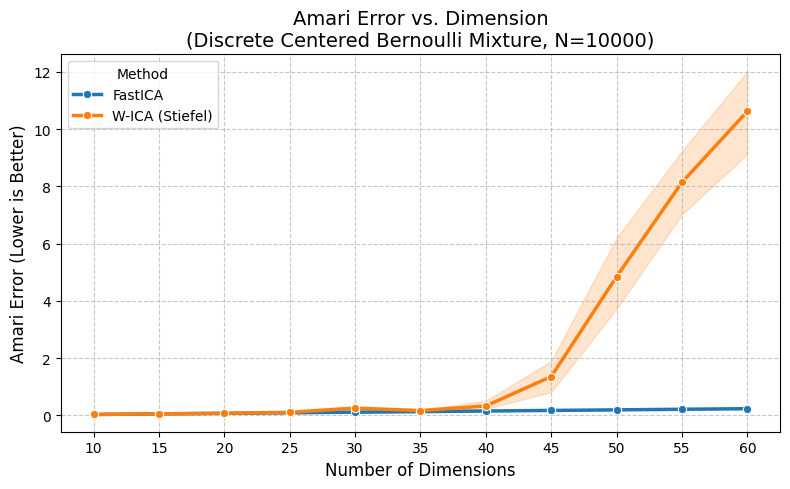

Method,FastICA,W-ICA (Stiefel)
Dimension,,
10,0.0333,0.0333
15,0.0559,0.0559
20,0.0733,0.0734
25,0.0917,0.1080
30,0.1125,0.2563
35,0.1322,0.1682
40,0.1538,0.3316
45,0.1745,1.3570
50,0.1942,4.8453


In [6]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_bernoulli, x='Dimension', y='Amari Error', hue='Method', marker='o', linewidth=2.5)
plt.title(f"Amari Error vs. Dimension\n(Discrete Centered Bernoulli Mixture, N={N_SAMPLES})", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.xticks(DIMENSIONS)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(df_bernoulli.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))